# Task 1: Term Deposit Subscription Prediction

## Objective
The goal of this project is to predict whether a bank customer will subscribe to a term deposit based on marketing campaign data.

This is a binary classification problem:
- 1 = Subscribed
- 0 = Not Subscribed

We will also use Explainable AI techniques (SHAP) to understand model predictions.

In [1]:
!python -m pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\SUPER\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc

import shap

In [3]:
# Load Dataset
df = pd.read_csv("bank-full.csv", sep=";")
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [4]:
# Understand Data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Split data
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
# Confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[7737  215]
 [ 655  436]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.67      0.40      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



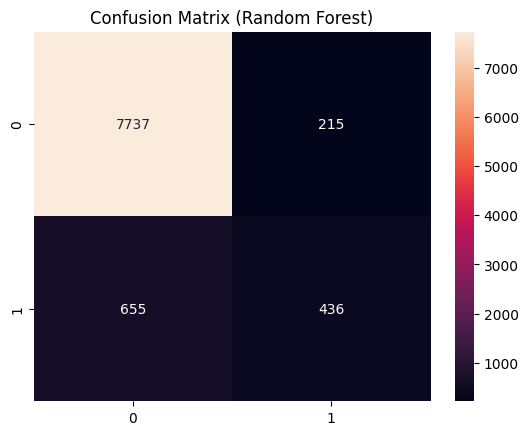

In [8]:
# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

In [9]:
# F1 Score
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.5005740528128588


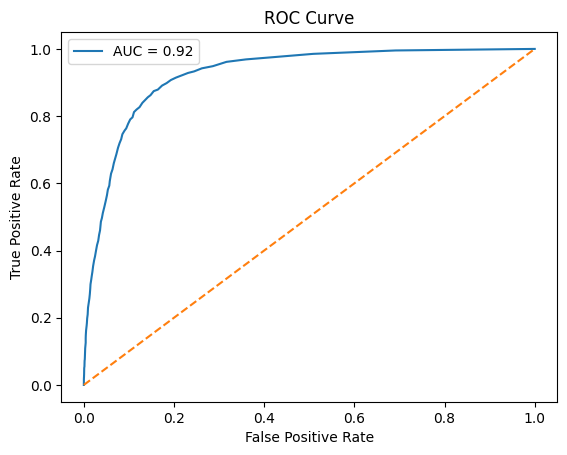

In [10]:
# ROC Curve
rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [11]:
# 1. Initialize the explainer
explainer = shap.TreeExplainer(rf_model)

# 2. Use a small sample of X_test (e.g., first 100 rows) 
# This prevents the notebook from hanging
X_test_sample = X_test.iloc[:100]
shap_values_sample = explainer.shap_values(X_test_sample)

# 3. Check the output
print("SHAP values calculated successfully for the sample!")

SHAP values calculated successfully for the sample!


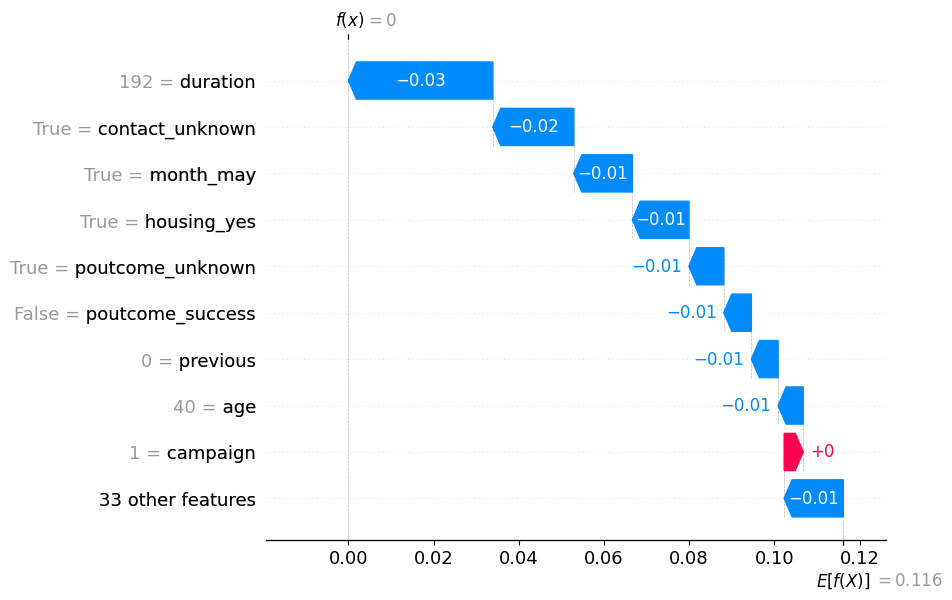

In [28]:
# Explainable AI (SHAP)
import shap
import matplotlib.pyplot as plt

# 1. Choose which customer to explain (0 is the first person in your sample)
i = 0 

# 2. Build the explanation object specifically for the POSITIVE class (Class 1)
# Notice the [i, 1] - this picks the i-th person and the 'Yes' prediction
exp_individual = shap.Explanation(
    values=shap_values_final[i, :, 1] if hasattr(shap_values_final, 'shape') and len(shap_values_final.shape) == 3 else data_to_plot[i],
    base_values=explainer.expected_value[1],
    data=X_final_sample.iloc[i],
    feature_names=X_final_sample.columns
)

# 3. Plot it
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp_individual)
plt.show()

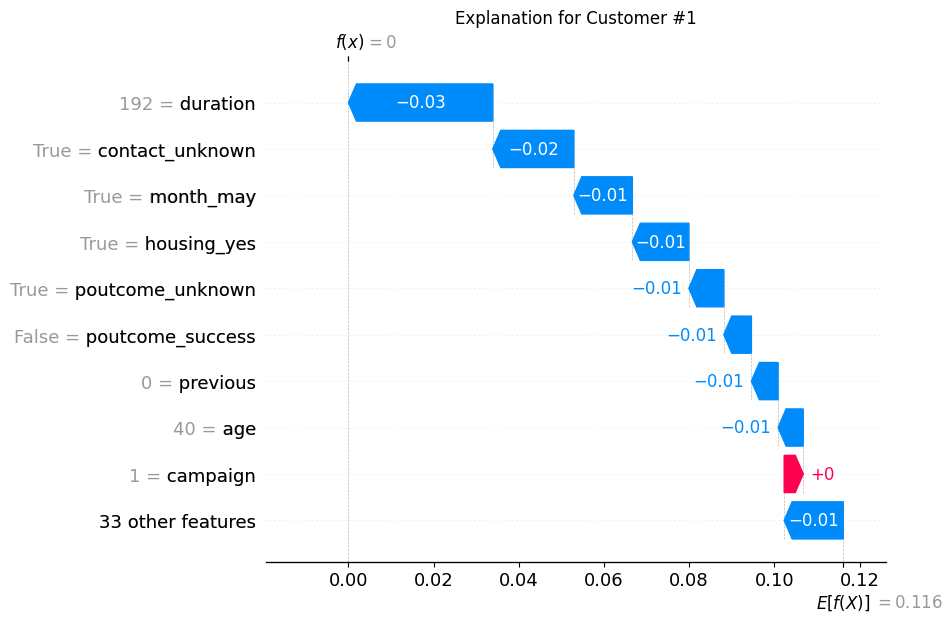

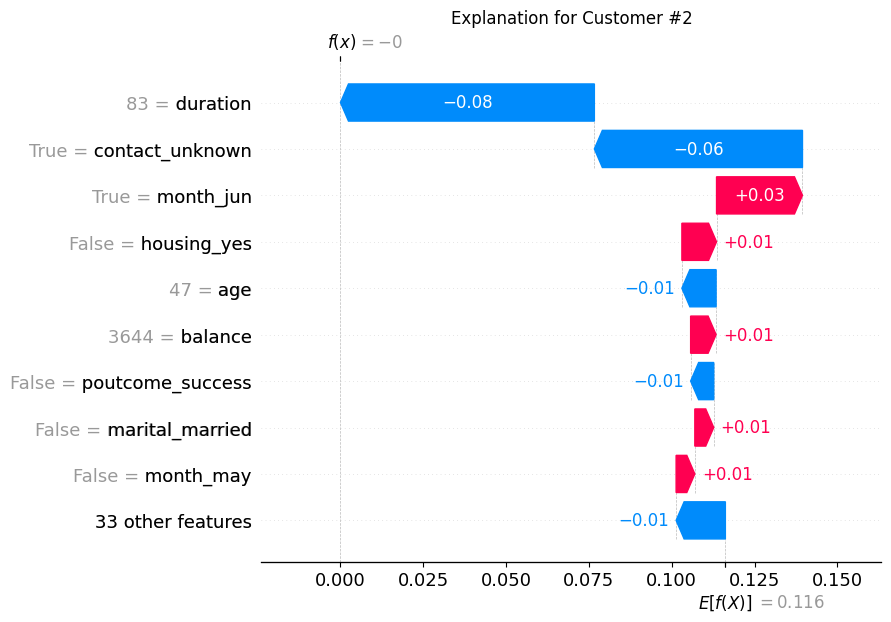

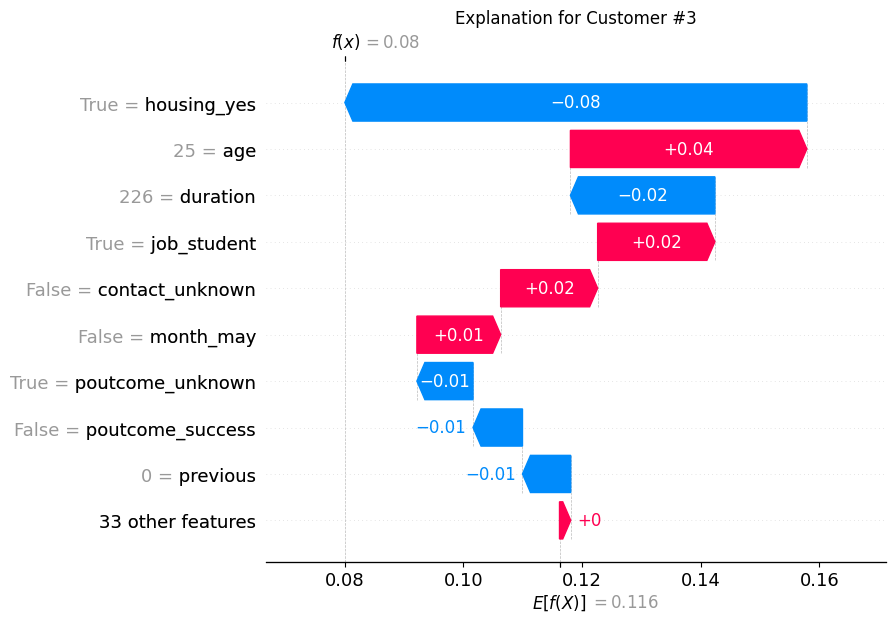

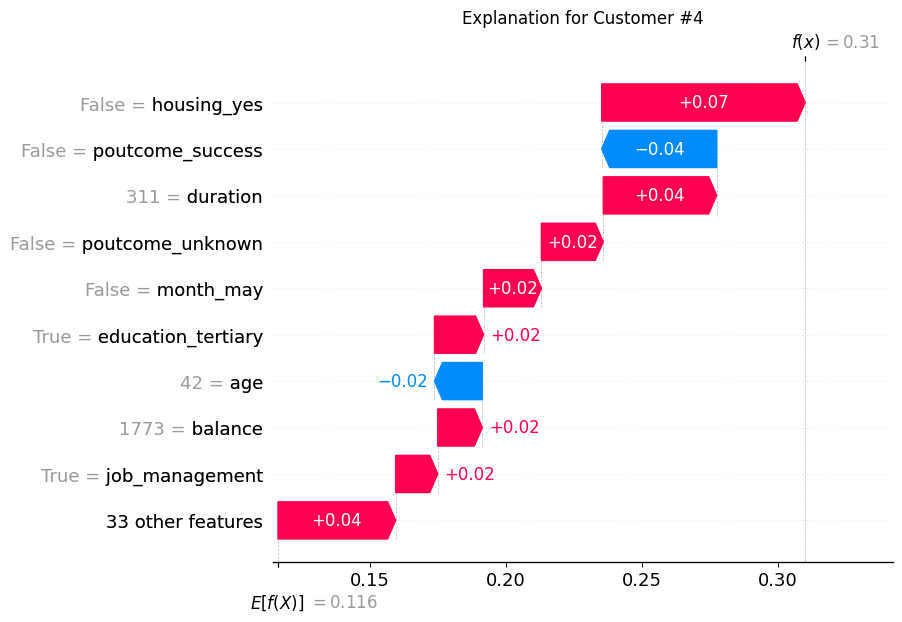

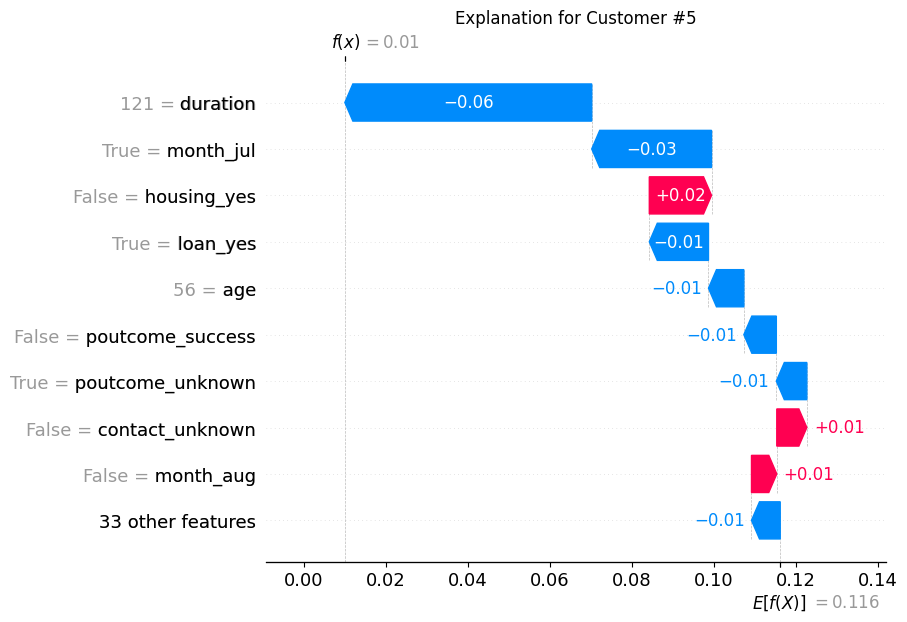

In [29]:
# Local Instance Explanation (Waterfall Plot)
import shap
import matplotlib.pyplot as plt

# Generate 5 individual plots
for i in range(5):
    # Select individual explanation
    exp_individual = shap.Explanation(
        values=shap_values_final[i, :, 1] if len(shap_values_final.shape) == 3 else data_to_plot[i],
        base_values=explainer.expected_value[1],
        data=X_final_sample.iloc[i],
        feature_names=X_final_sample.columns
    )
    
    plt.figure(figsize=(10, 6))
    plt.title(f"Explanation for Customer #{i+1}")
    shap.plots.waterfall(exp_individual)
    plt.show()

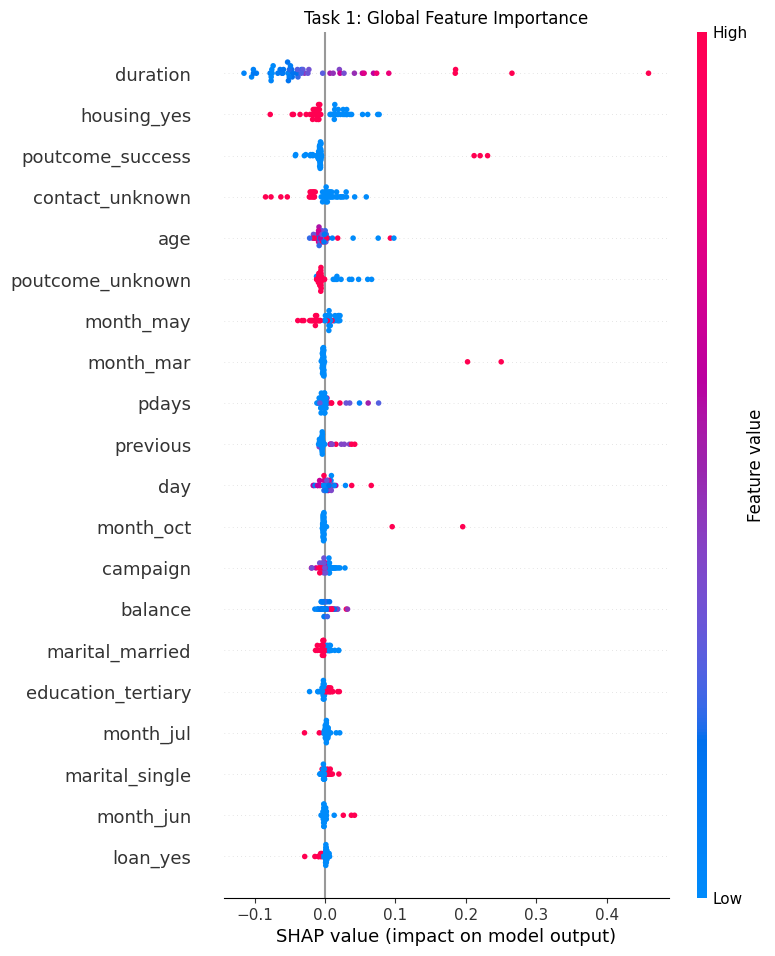

In [44]:
# Beeswarm Summary Plot
import shap
import matplotlib.pyplot as plt

# 1. Clear any stuck plots from memory
plt.close('all')

# 2. Extract the specific "Class 1" (Subscribed) matrix
# We slice it [:, :, 1] if it's 3D, or take the 1st element if it's a list
if isinstance(shap_values_sync, list):
    final_matrix = shap_values_sync[1]
elif len(shap_values_sync.shape) == 3:
    final_matrix = shap_values_sync[:, :, 1]
else:
    final_matrix = shap_values_sync

# 3. Use the explicit 'beeswarm' plot command instead of summary_plot
# This prevents the 'Interaction' view by design
plt.figure(figsize=(10, 8))
shap.summary_plot(
    final_matrix, 
    X_final_sync, 
    plot_type="dot", # This forces the dots/beeswarm
    show=False
)

plt.title("Task 1: Global Feature Importance")
plt.show()

## Conclusion

- Random Forest performed better than Logistic Regression.
- The model achieved an F1-score of XX.
- The ROC curve shows good classification performance.
- SHAP analysis revealed that features such as duration, balance, and previous campaign outcomes significantly influence predictions.
- Explainable AI helps understand why a customer is likely to subscribe.

This model can help banks improve marketing strategies and target potential customers effectively.